In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split    # Train/test split
from sklearn.pipeline import Pipeline                  # Pipeline to prevent leakage
from sklearn.compose import ColumnTransformer        # Different preprocessing per column type
from sklearn.preprocessing import  RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression  , Lasso 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.svm import SVR
from sklearn.model_selection import learning_curve, GridSearchCV , RandomizedSearchCV
from scipy.stats import uniform, loguniform


In [31]:
df=pd.read_csv(R"..\data\train_clean.csv")
df

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.0,58.0,1.75,MARUTI,WAGON R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.0,126.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION
2,Chennai,2011,46000,Petrol,Manual,First,18.0,88.0,4.50,HONDA,JAZZ V
3,Chennai,2012,87000,Diesel,Manual,First,20.0,88.0,6.00,MARUTI,ERTIGA VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.0,140.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC
...,...,...,...,...,...,...,...,...,...,...,...
6008,Delhi,2014,27365,Diesel,Manual,First,28.0,74.0,4.75,MARUTI,SWIFT VDI
6009,Jaipur,2015,100000,Diesel,Manual,First,24.0,71.0,4.00,HYUNDAI,XCENT 1.1 CRDI S
6010,Jaipur,2012,55000,Diesel,Manual,Second,14.0,112.0,2.90,MAHINDRA,XYLO D4 BSIV
6011,Kolkata,2013,46000,Petrol,Manual,First,18.0,67.0,2.65,MARUTI,WAGON R VXI


In [32]:
df.Power.isnull().sum()

np.int64(0)

In [33]:
df["Power"] = df["Power"].replace(["null", "NaN", "-", "unknown"], np.nan)

In [34]:
df.dropna(subset=["Power"])

,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Power,Price,Brand,Model
0,Mumbai,2010,72000,CNG,Manual,First,26.0,58.0,1.75,MARUTI,WAGON R LXI CNG
1,Pune,2015,41000,Diesel,Manual,First,19.0,126.0,12.50,HYUNDAI,CRETA 1.6 CRDI SX OPTION
2,Chennai,2011,46000,Petrol,Manual,First,18.0,88.0,4.50,HONDA,JAZZ V
3,Chennai,2012,87000,Diesel,Manual,First,20.0,88.0,6.00,MARUTI,ERTIGA VDI
4,Coimbatore,2013,40670,Diesel,Automatic,Second,15.0,140.0,17.74,AUDI,A4 NEW 2.0 TDI MULTITRONIC
...,...,...,...,...,...,...,...,...,...,...,...
6008,Delhi,2014,27365,Diesel,Manual,First,28.0,74.0,4.75,MARUTI,SWIFT VDI
6009,Jaipur,2015,100000,Diesel,Manual,First,24.0,71.0,4.00,HYUNDAI,XCENT 1.1 CRDI S
6010,Jaipur,2012,55000,Diesel,Manual,Second,14.0,112.0,2.90,MAHINDRA,XYLO D4 BSIV
6011,Kolkata,2013,46000,Petrol,Manual,First,18.0,67.0,2.65,MARUTI,WAGON R VXI


In [35]:
x=df.drop(columns=["Price"])
y=df["Price"]


In [36]:
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()   # Numeric columns list.tolist()  
categorical_features = x.select_dtypes(exclude=[np.number]).columns.tolist()

In [37]:
numeric_features

['Year', 'Kilometers_Driven', 'Mileage', 'Power']

In [38]:
categorical_features

['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand', 'Model']

In [39]:
#convertit des données nominales aux valeurs numériques 1 2 3 4 5
# df["Fuel_Type"]=pd.factorize(df["Fuel_Type"])[0]
# df["Transmission"]=pd.factorize(df["Transmission"])[0]
# df["Owner_Type"]=pd.factorize(df["Owner_Type"])[0]
# df["Brand"]=pd.factorize(df["Brand"])[0]
# df["Model"]=pd.factorize(df["Model"])[0]
# df
#df = pd.get_dummies(df, columns=["Transmission", "Owner_Type", "Model","Brand"], dtype=float)

In [40]:
# df= df.drop(["Fuel_Type"], axis=1)
# df

In [41]:

# Séparer x et y
x = df.drop(columns=["Price"])
y = df["Price"]

# Colonnes
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(exclude=[np.number]).columns.tolist()

# Transformations
numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("numerique", numeric_transformer, numeric_features),
        ("categorial", categorical_transformer, categorical_features)
    ]
)

# Pipeline complet
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])

# Split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, train_size=0.8, random_state=42)
print(x_train.shape , x_test.shape) 
# Entraînement
model.fit(x_train, y_train)


(4810, 10) (1203, 10)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerique', ...), ('categorial', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [42]:
y_pred = model.predict(x_test)
mse=mean_squared_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test , y_pred)
mae=mean_absolute_error(y_test, y_pred)
r2=r2_score(y_test , y_pred)

print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R²   : {r2:.4f}")

MSE  : 23.98
RMSE : 4.90
MAE  : 2.19
R²   : 0.8054


c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


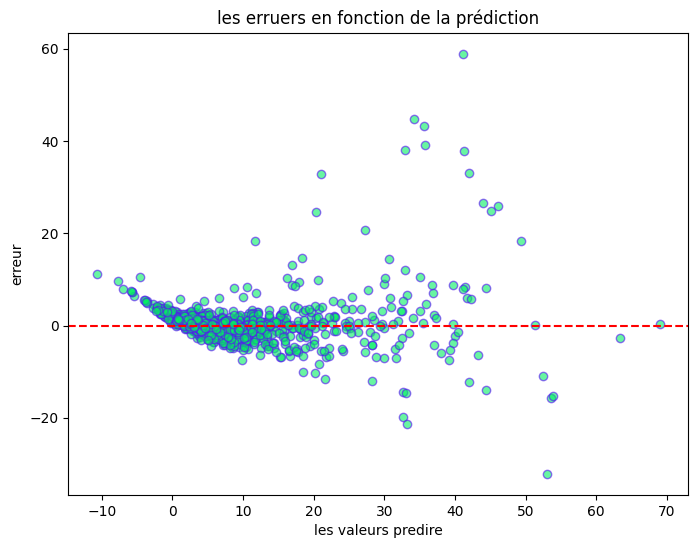

In [43]:
erreur=y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred, erreur,  color="#03EF62", alpha=0.6 , edgecolors="#5511F5")
plt.axhline(0, color="red", linestyle= "--")
plt.xlabel("les valeurs predire")
plt.ylabel("erreur")
plt.title("les erruers en fonction de la prédiction")
plt.show()


c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 3, 4, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\samya.taqi

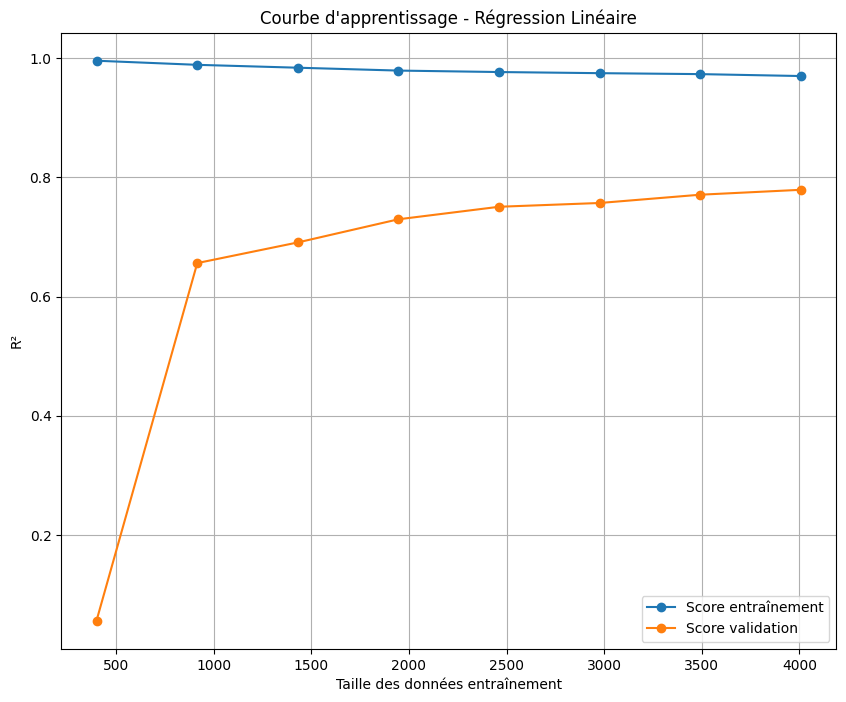

In [44]:
train_sizes, train_scores, test_scores = learning_curve(
    model,
    x,
    y,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=42
)

# Moyennes
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Graphique
plt.figure(figsize=(10,8))

plt.plot(train_sizes, train_mean, marker='o', label="Score entraînement")
plt.plot(train_sizes, test_mean, marker='o', label="Score validation")

plt.xlabel("Taille des données entraînement")
plt.ylabel("R²")
plt.title("Courbe d'apprentissage - Régression Linéaire")
plt.legend()
plt.grid()
plt.show()


In [45]:

# Séparer x et y
x = df.drop(columns=["Price"])
y = df["Price"]

# Colonnes
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(exclude=[np.number]).columns.tolist()

# Transformations
numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("numerique", numeric_transformer, numeric_features),
        ("categorial", categorical_transformer, categorical_features)
    ]
)

# Pipeline complet
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", Lasso(alpha=0.1))
])

# Split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)
print(x_train.shape , x_test.shape) 
# Entraînement
model.fit(x_train, y_train)

(4810, 10) (1203, 10)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerique', ...), ('categorial', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [46]:
# Faire des prédictions
y_pred = model.predict(x_test)

# Évaluer
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
print("--- LASSO---")
print(f"MSE = {mse:.2f}")
print(f'MAE = {mae:.2f}')
print(f"RMSE = {rmse:.2f}")
print(f"R²  = {r2:.2f}")

--- LASSO---
MSE = 32.97
MAE = 3.42
RMSE = 5.74
R²  = 0.73


c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


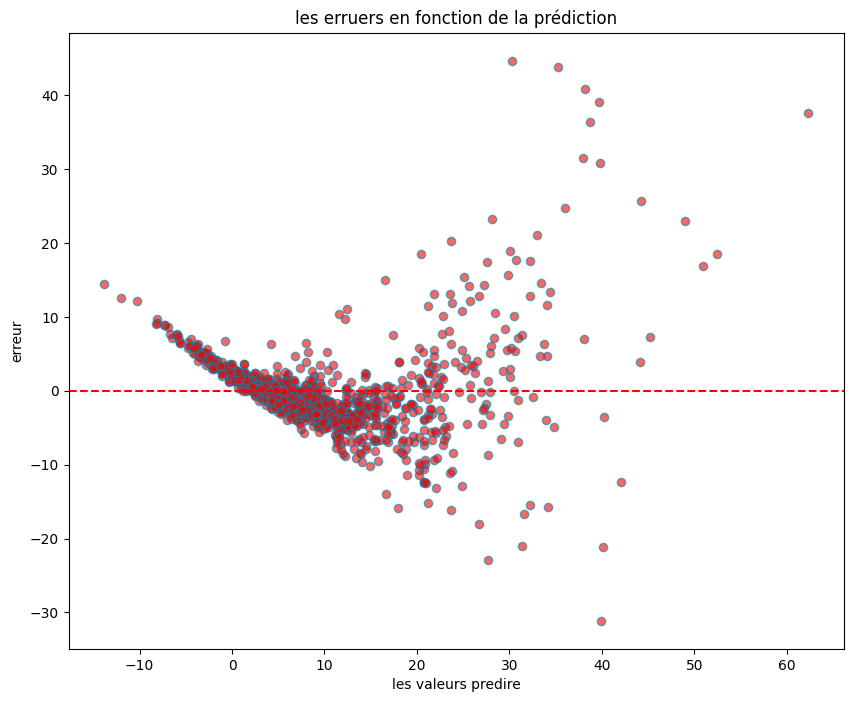

In [47]:
erreur=y_test - y_pred
plt.figure(figsize=(10,8))
plt.scatter(y_pred, erreur,  color="#EF0303", alpha=0.6 , edgecolors="#0D83A7")
plt.axhline(0, color="red", linestyle= "--")
plt.xlabel("les valeurs predire")
plt.ylabel("erreur")
plt.title("les erruers en fonction de la prédiction")
plt.show()

**SVR**

In [48]:
# Séparer x et y
x = df.drop(columns=["Price"])
y = df["Price"]

# Colonnes
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(exclude=[np.number]).columns.tolist()

# Transformations
numeric_transformer = Pipeline(steps=[
    ("scaler", RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("numerique", numeric_transformer, numeric_features),
        ("categorial", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svm", SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale"))
])

# Split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)
print(x_train.shape , x_test.shape) 
# Entraînement
model.fit(x_train, y_train)

(4810, 10) (1203, 10)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerique', ...), ('categorial', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

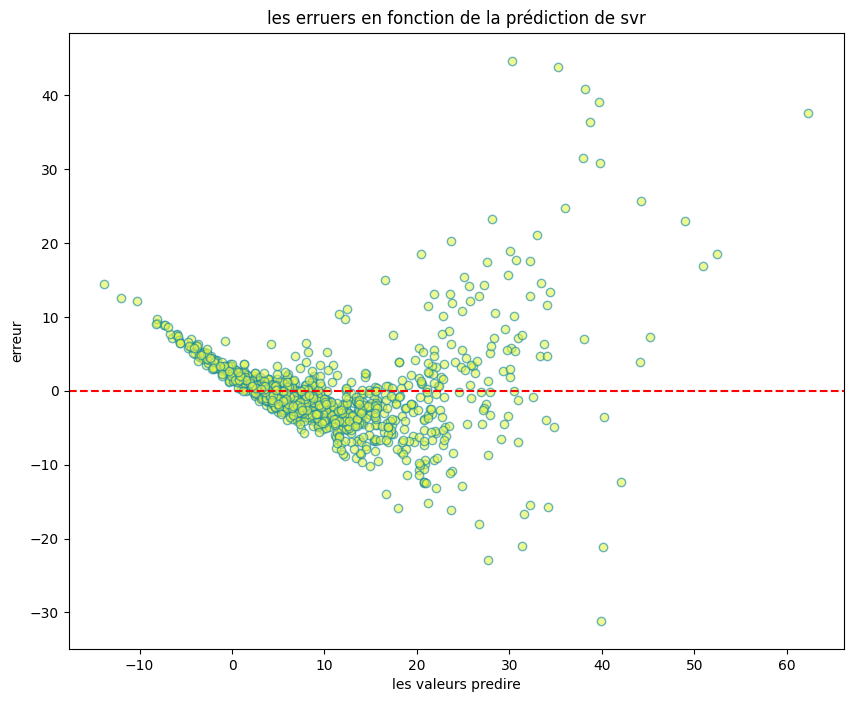

In [49]:
erreur=y_test - y_pred
plt.figure(figsize=(10,8))
plt.scatter(y_pred, erreur,  color="#E4F549", alpha=0.6 , edgecolors="#0D83A7")
plt.axhline(0, color="red", linestyle= "--")
plt.xlabel("les valeurs predire")
plt.ylabel("erreur")
plt.title("les erruers en fonction de la prédiction de svr")
plt.show()

**RandomizeSearchCV**

In [50]:
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

param_dist = {
    "svm__C": loguniform(0.1, 1000),
    "svm__epsilon": uniform(0.01, 1),
    "svm__gamma": loguniform(0.0001, 1)
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=30,              # nombre de combinaisons testées
    cv=5,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)
best_model = random_search.best_estimator_


print("Best parameters:", random_search.best_params_)
print("Best CV score (MSE):", -random_search.best_score_)

Best parameters: {'svm__C': np.float64(624.5139574743067), 'svm__epsilon': np.float64(0.9756320330745594), 'svm__gamma': np.float64(0.17123375973163968)}
Best CV score (MSE): 12.743249256962182


In [51]:
y_pred = best_model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 1.5160532232723871
MSE : 10.817775260408906
RMSE : 3.289038652921079
R2 : 0.9121993236997383


c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [52]:
train_score = best_model.score(x_train, y_train)
test_score = best_model.score(x_test, y_test)

print("R2 Train:", train_score)
print("R2 Test :", test_score)
print("interprétation: sur le train: le modèle s'adapte extrêmement bien aux données qu'il a vues \n sur le test: best score ")

R2 Train: 0.9956661624835966
R2 Test : 0.9121993236997383
interprétation: sur le train: le modèle s'adapte extrêmement bien aux données qu'il a vues 
 sur le test: best score 


c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [53]:
y_pred=model.predict(x_test)
# Évaluer
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)

print(f"RMSE = {rmse:.2f}")

print(f"MSE = {mse:.2f}")
print(f"R²  = {r2:.2f}")

c:\Users\samya.taqi\Desktop\SAMYA TAQI\Pr-dire-le-prix-de-voiture--projet-r-gression\price_car\pricecarenv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


RMSE = 3.20
MSE = 10.26
R²  = 0.92


# xgbOOST

In [87]:
import pandas as pd 
import numpy as np
import joblib 
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.metrics import mean_absolute_error ,r2_score, mean_squared_error

In [88]:
df=pd.read_csv(r"..\data\train_clean.csv")


x=df.drop(["Price"], axis=1)
y=df["Price"]

# Colonnes
numeric_features = x.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = x.select_dtypes(exclude=[np.number]).columns.tolist()

preprocesseur=ColumnTransformer(
    transformers=[
        ('numérique',StandardScaler(), numeric_features),
        ('catégorial',OneHotEncoder(handle_unknown='ignore'), categorical_features) #si on choisie une marque inexistante, model va pas planter mais il va ignorer 
    ]
)

pipe=Pipeline([
    ('preprocesseur', preprocesseur),
    ('model',XGBRegressor(objective='reg:squarederror',random_state=42))
])

params_grid = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

x_train, x_test, y_train, y_test= train_test_split(x, y , test_size=0.2, train_size=0.8 ,random_state=42)
rgr_model=GridSearchCV(pipe, params_grid,  cv=3 , scoring='r2', n_jobs=-1 , verbose=1)
rgr_model.fit(x_train, y_train)



Fitting 3 folds for each of 54 candidates, totalling 162 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], 'model__n_estimators': [100, 300, ...], 'model__subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time 

In [89]:
y_pred=rgr_model.predict(x_test)
mse= mean_squared_error(y_test, y_pred)
mae=mean_absolute_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print("--xgboost + gridsearch--")
print(f"MSE = {mse}")
print(f"MAE = {mae}")
print(f"RMSE = {rmse}")
print(f"R² = {r2}")

--xgboost + gridsearch--
MSE = 6.941091674324331
MAE = 1.3990734912352272
RMSE = 2.6345951632697444
R² = 0.9436637821920553


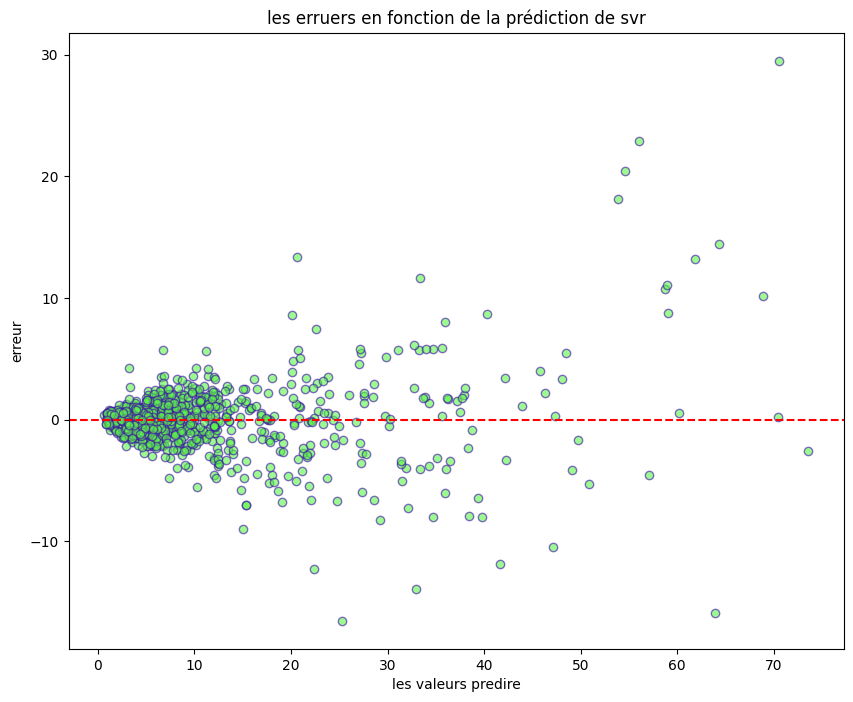

In [91]:
erreur=y_test - y_pred
plt.figure(figsize=(10,8))
plt.scatter(y_pred, erreur,  color="#5DF549", alpha=0.6 , edgecolors="#3B0DA7")
plt.axhline(0, color="red", linestyle= "--")
plt.xlabel("les valeurs predire")
plt.ylabel("erreur")
plt.title("les erruers en fonction de la prédiction de svr")
plt.show()

# catboost

In [98]:
from catboost import CatBoostRegressor

In [99]:
x= df.drop(["Price"], axis=1)
y=df["Price"]

In [100]:
cat_cols = x.select_dtypes(exclude=[np.number]).columns.tolist()

for col in cat_cols:
    temp = pd.get_dummies(df[col]).astype('int')
    df = pd.concat([df, temp], axis=1)

df.drop(cat_cols, axis=1, inplace=True)
print(df.head())

   Year  Kilometers_Driven  Mileage  Power  Price  Ahmedabad  Bangalore  \
0  2010              72000     26.0   58.0   1.75          0          0   
1  2015              41000     19.0  126.0  12.50          0          0   
2  2011              46000     18.0   88.0   4.50          0          0   
3  2012              87000     20.0   88.0   6.00          0          0   
4  2013              40670     15.0  140.0  17.74          0          0   

   Chennai  Coimbatore  Delhi  ...  ZEN VXI - BS III  ZEN VXI BSII  \
0        0           0      0  ...                 0             0   
1        0           0      0  ...                 0             0   
2        1           0      0  ...                 0             0   
3        1           0      0  ...                 0             0   
4        0           1      0  ...                 0             0   

   ZEST QUADRAJET 1.3  ZEST QUADRAJET 1.3 75PS XE  ZEST QUADRAJET 1.3 75PS XM  \
0                   0                          

In [101]:
x_train, x_test , y_train , y_test= train_test_split(x, y, random_state = 42, test_size=0.3)


In [102]:
model=CatBoostRegressor(loss_function='RMSE')

model.fit(x_train , y_train,  verbose=100)

Learning rate set to 0.051381
0:	learn: 10.2500084	total: 6.7ms	remaining: 6.7s
100:	learn: 3.1018994	total: 596ms	remaining: 5.3s
200:	learn: 2.6625420	total: 1.18s	remaining: 4.7s
300:	learn: 2.3814629	total: 1.76s	remaining: 4.1s
400:	learn: 2.2021161	total: 2.35s	remaining: 3.52s
500:	learn: 2.0591090	total: 2.94s	remaining: 2.93s
600:	learn: 1.9288752	total: 3.52s	remaining: 2.34s
700:	learn: 1.8407449	total: 4.1s	remaining: 1.75s
800:	learn: 1.7506834	total: 4.68s	remaining: 1.16s
900:	learn: 1.6786653	total: 5.26s	remaining: 578ms
999:	learn: 1.6118115	total: 5.83s	remaining: 0us


CatBoostRegressor(loss_function='RMSE')

In [103]:
y_pred=model.predict(x_test)
print("--CatBoost--")
mae=mean_absolute_error(y_test, y_pred)
mse=mean_absolute_error(y_test, y_pred)
rmse=root_mean_squared_error(y_test, y_pred)
r2=r2_score(y_test, y_pred)
print(f"MSE= {mse}")
print(f"MAE= {mae}")
print(f"RMSE= {rmse}")
print(f"R²= {r2}")


--CatBoost--
MSE= 1.56259890408357
MAE= 1.56259890408357
RMSE= 4.0299234135079605
R²= 0.8885137546712646


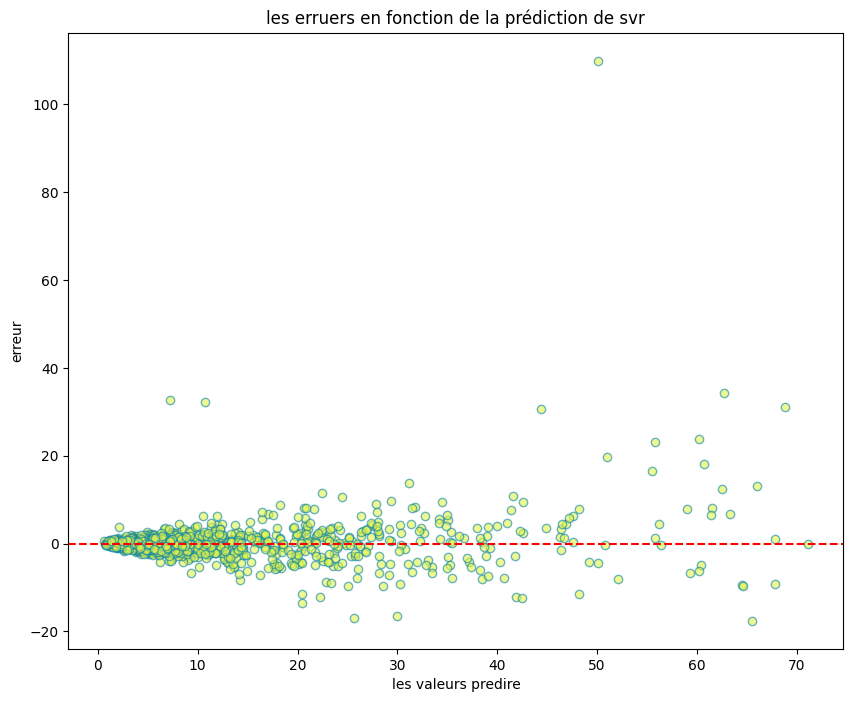

In [104]:
erreur=y_test - y_pred
plt.figure(figsize=(10,8))
plt.scatter(y_pred, erreur,  color="#E4F549", alpha=0.6 , edgecolors="#0D83A7")
plt.axhline(0, color="red", linestyle= "--")
plt.xlabel("les valeurs predire")
plt.ylabel("erreur")
plt.title("les erruers en fonction de la prédiction de svr")
plt.show()